In [ ]:
# 실습 라이브러리(lib) 준비 — 교재 저장소에서 자동으로 받아옵니다 (Google Drive 불필요)
import os, sys
path = "/content/"
if not os.path.isdir(path + "lib"):
    !git clone -q --depth 1 https://github.com/AI-BoostCamp/ReinforcementLearning.git /content/_rl && cp -r /content/_rl/code/lib /content/lib && rm -rf /content/_rl
sys.path.append(path + "lib")
os.makedirs(path + "models/DRL", exist_ok=True)   # 학습된 모델 저장 위치 (세션 종료 시 사라짐)


In [2]:
from variable_print import p,ps,pst

In [3]:
import gymnasium as gym
env = gym.make("CartPole-v1", render_mode="rgb_array")
print(gym.__version__)  #0.25.2
print("="*10)
print('State space: ', env.observation_space)
print('Action space: ', env.action_space)

1.2.0
State space:  Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space:  Discrete(2)


# Neural Network 적용

In [4]:
import random
import numpy as np
from collections import deque
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import time

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 3.5]
plt.rcParams["font.size"] = "8"

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [5]:
"""## 하이퍼파라미터 설정"""

# 학습 관련
learning_rate = 0.001
gamma = 0.99
batch_size = 64
memory_size = 10000

# total episode steps
n_episode = 100

# Epsilon-Greedy 정책 관련
epsilon_start = 0.5
epsilon_end = 0.01
eps_decay = 0.6   # 감소율
epsilon_decay_steps = n_episode // 3

# Model

### Neural Model

In [6]:
class QNetwork(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, output_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [7]:
"""## DQNAgent 클래스 정의"""

class DQNAgent:
    def __init__(self, env):
        self.env = env
        self.state_size = env.observation_space.shape[0]
        self.action_size = env.action_space.n
        self.epsilon = epsilon_start

        # Experience Replay를 위한 메모리
        self.memory = deque(maxlen=memory_size)

        # Q-Network와 Target Network 생성
        self.q_network = QNetwork(self.state_size, self.action_size)
        self.target_q_network = QNetwork(self.state_size, self.action_size)
        # Target Network의 가중치를 Q-Network와 동일하게 초기화
        self.update_target_model()

        self.optimizer = optim.Adam(self.q_network.parameters(), lr=learning_rate)
        self.criterion = nn.MSELoss()

    def remember(self, state, action, reward, next_state, done):
        """경험(Experience)을 메모리에 저장"""
        self.memory.append((state, action, reward, next_state, done))

    def get_action(self, state):
        """Epsilon-Greedy 정책에 따라 행동 선택"""
        if random.random() < self.epsilon:
            return self.env.action_space.sample()
        else:
            with torch.no_grad():
                state_tensor = torch.FloatTensor(state).unsqueeze(0)
                q_values = self.q_network(state_tensor)
                return torch.argmax(q_values).item()

    def replay(self):
        """메모리에서 샘플링한 배치로 모델을 학습 (Experience Replay)"""
        if len(self.memory) < batch_size:
            return 0 # 학습할 데이터가 충분하지 않으면 종료

        # 메모리에서 미니배치 랜덤 샘플링
        minibatch = random.sample(self.memory, batch_size)

        # 각 데이터(state, action, ...)를 텐서로 변환
        states = torch.FloatTensor(np.array([t[0] for t in minibatch]))
        actions = torch.LongTensor([t[1] for t in minibatch]).unsqueeze(1)
        rewards = torch.FloatTensor([t[2] for t in minibatch]).unsqueeze(1)
        next_states = torch.FloatTensor(np.array([t[3] for t in minibatch]))
        dones = torch.FloatTensor([t[4] for t in minibatch]).unsqueeze(1)

        # 1. 현재 상태(state)에 대한 Q-value 예측
        #    실제 선택한 행동(action)에 대한 Q-value만 가져옴
        current_q_values = self.q_network(states).gather(1, actions)

        # 2. Target Q-value 계산
        with torch.no_grad():
            # Target Network를 사용하여 다음 상태(next_state)의 최대 Q-value 계산
            max_next_q_values = self.target_q_network(next_states).max(1)[0].unsqueeze(1)
            # Bellman Equation을 이용한 Target Q-value
            target_q_values = rewards + (1 - dones) * gamma * max_next_q_values

        # Loss 계산 및 모델 업데이트
        loss = self.criterion(current_q_values, target_q_values)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return loss.item()

    def update_target_model(self):
        """Target Network의 가중치를 Q-Network의 가중치로 복사"""
        self.target_q_network.load_state_dict(self.q_network.state_dict())

    def decay_epsilon(self,step):
        """Epsilon 값 감소"""
        self.epsilon = max(0.01, epsilon_start*eps_decay**(step//epsilon_decay_steps))

    def save_model(self, path):
        torch.save(self.q_network.state_dict(), path)
        print(f"모델이 {path}에 저장되었습니다.")

    def load_model(self, path):
        self.q_network.load_state_dict(torch.load(path))
        self.q_network.eval()
        print(f"모델을 {path}에서 불러왔습니다.")

In [8]:
%%time
"""## 학습 루프"""
#model_path = path+"models/DRL/DQN.pth"
model_path = path+"DQN.pth"
#######
# Target Network 업데이트 주기
target_update_freq = 5 # episodes
max_score = 50

agent = DQNAgent(env)
scores = []
losses = []

print("학습을 시작합니다...")
for e in range(1, n_episode+1): # 에피소드 수 증가
    state = env.reset()
    if isinstance(state, tuple): state = state[0]

    done = False
    score = 0

    while not done:
        action = agent.get_action(state)
        next_state, reward, done, _ , _= env.step(action)
        # 경험을 메모리에 저장
        agent.remember(state, action, reward, next_state, done)

        # 메모리에서 샘플링하여 모델 학습
        loss = agent.replay()
        if loss is not None: losses.append(loss)

        state = next_state
        score += reward
        agent.decay_epsilon(e)

    scores.append(score)

    # 주기적으로 Target Network 업데이트
    if e % target_update_freq == 0:
        agent.update_target_model()
        print(f"Episode {e}: Target network updated.")

    mean_score = np.mean(scores[-10:]) # 최근 100개 에피소드 평균 점수
    print(f"Episode {e}, Score: {score}, Avg Score: {mean_score:.2f}, Epsilon: {agent.epsilon:.4f}")

    # 최고 점수 모델 저장
    if mean_score > max_score :
        max_score = mean_score
        agent.save_model(model_path)
        print(f"New best model saved with avg score: {max_score:.2f}")

    # 목표 점수 도달 시 조기 종료
    if mean_score >= 100 :
        print("목표 점수 도달! 학습을 종료합니다.")
        break

env.close()
print("학습 종료!")
# Wall time: 8.85 s

학습을 시작합니다...
Episode 1, Score: 14.0, Avg Score: 14.00, Epsilon: 0.5000
Episode 2, Score: 17.0, Avg Score: 15.50, Epsilon: 0.5000
Episode 3, Score: 12.0, Avg Score: 14.33, Epsilon: 0.5000
Episode 4, Score: 10.0, Avg Score: 13.25, Epsilon: 0.5000
Episode 5: Target network updated.
Episode 5, Score: 14.0, Avg Score: 13.40, Epsilon: 0.5000
Episode 6, Score: 9.0, Avg Score: 12.67, Epsilon: 0.5000
Episode 7, Score: 16.0, Avg Score: 13.14, Epsilon: 0.5000
Episode 8, Score: 12.0, Avg Score: 13.00, Epsilon: 0.5000
Episode 9, Score: 19.0, Avg Score: 13.67, Epsilon: 0.5000
Episode 10: Target network updated.
Episode 10, Score: 12.0, Avg Score: 13.50, Epsilon: 0.5000
Episode 11, Score: 10.0, Avg Score: 13.10, Epsilon: 0.5000
Episode 12, Score: 15.0, Avg Score: 12.90, Epsilon: 0.5000
Episode 13, Score: 14.0, Avg Score: 13.10, Epsilon: 0.5000
Episode 14, Score: 13.0, Avg Score: 13.40, Epsilon: 0.5000
Episode 15: Target network updated.
Episode 15, Score: 13.0, Avg Score: 13.30, Epsilon: 0.5000
Episo

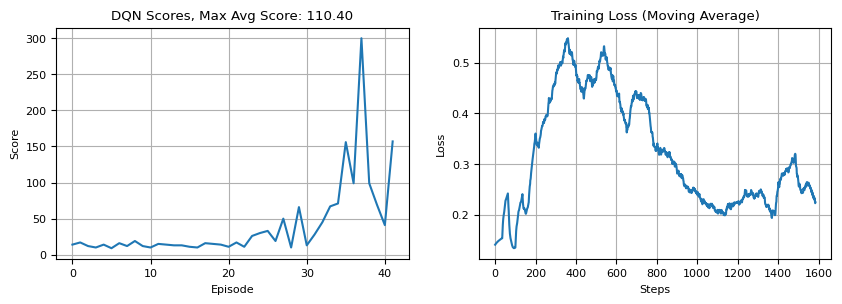

In [9]:
"""## 학습 결과 시각화"""

# Loss 그래프 (Moving Average)
def plot_moving_avg(data, window_size):
    moving_avg = np.convolve(data, np.ones(window_size)/window_size, mode='valid')
    plt.plot(moving_avg)

plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
plt.plot(scores)
plt.title(f'DQN Scores, Max Avg Score: {max_score:.2f}')
plt.xlabel('Episode')
plt.ylabel('Score')
plt.grid()

plt.subplot(1, 2, 2)
plot_moving_avg(losses, 100) # Loss는 변동이 크므로 이동 평균으로 시각화
plt.title('Training Loss (Moving Average)')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.grid()
plt.show()

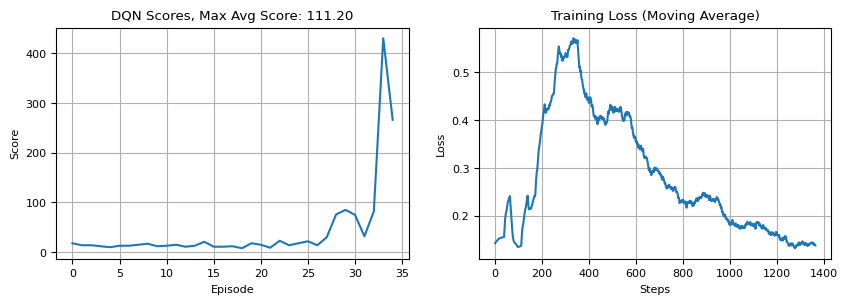

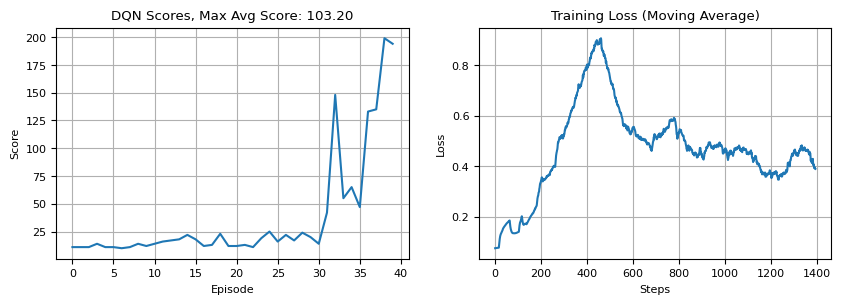

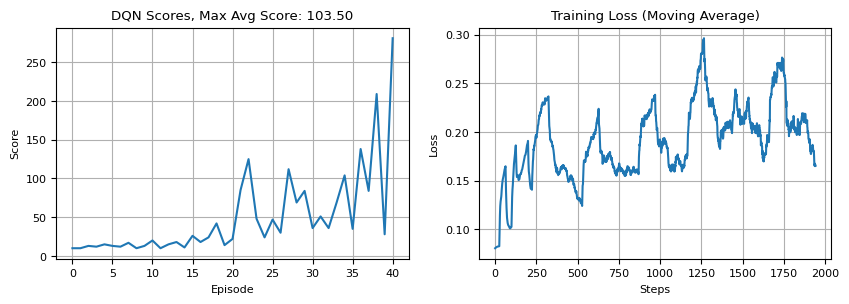

# Evaluation  

In [10]:
%%capture
!pip install pyvirtualdisplay
!sudo apt-get update
!sudo apt-get install python-opengl
!sudo apt-get install -f
!sudo apt-get upgrade --fix-missing
!sudo apt-get install xvfb

In [11]:
from pyvirtualdisplay import Display
virtual_display = Display(visible=0, size=(400, 300))
virtual_display.start()

In [12]:
from render import  show_video, wrap_env, render_as_image

In [13]:
env_v = wrap_env(env, path=path, name_prefix="q2")

/usr/local/lib/python3.11/dist-packages/gymnasium/wrappers/rendering.py:296: UserWarning: WARN: Overwriting existing videos at /content/gdrive/MyDrive/Colab Notebooks/video folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


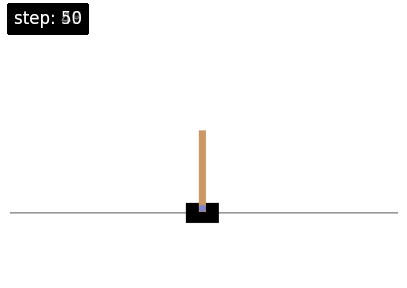

In [ ]:
state = env_v.reset()
if isinstance(state, tuple): state = state[0]
cnt = 0
while True:
    render_as_image(env_v,step=cnt)
    action = agent.get_action(state)
    state, reward, done, info,_ = env_v.step(action)
    if done:  break;
    cnt += 1
    if cnt > 50 : break
env_v.close()

$$J(\theta) = (1-\gamma)V^{\pi}(s_0)$$이때 **방문 빈도**는 감가율을 포함하여 다음과 같이 정의됩니다.$$\eta(s) = \sum_{k=0}^{\infty} \gamma^k P(s_k=s | s_0)$$이 경우, 모든 상태의 방문 빈도의 합인 **상수항**은 다음과 같이 계산됩니다.$$\sum_s \eta(s) = \frac{1}{1-\gamma}$$

따라서 유도 과정에 있던 목표 함수의 정의에 포함된 (1−γ) 항과, 중간 과정에서 나타난 상수항 $\frac{1}{1-\gamma}$이 서로 곱해지면서 정확히 1이 되어 상쇄됩니다.

In [ ]:
show_video(path=path,name_prefix='q2')

/content/gdrive/MyDrive/Colab Notebooks/video/q2-episode-0.mp4


In [ ]:
show_video(path=path,name_prefix='q2')

/content/gdrive/MyDrive/Colab Notebooks/video/q2-episode-0.mp4


In [ ]:
show_video(path=path,name_prefix='q2')

/content/gdrive/MyDrive/Colab Notebooks/video/q2-episode-0.mp4


# 실습과제   
## Hyper Parameter tuning해 보자  
### n_episode = 75 로 고정하고 다음을 조정해서 성능을 개선해 보자  
#### eps_start = 0.5   
#### batch_siae = 128  
#### epochs = 1  
#### len(RM) > batch_size * 3